In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [28]:
from datasets import load_dataset

dataset = load_dataset("imdb", cache_dir="./data")
train_data = dataset["train"]
test_data = dataset["test"]

# Tokenization

In [29]:
from transformers import AutoTokenizer
tokeniser = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokeniser(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=200
    )

In [ ]:
train_data = train_data.map(tokenize,batched=True)

In [31]:
test_data = test_data.map(tokenize,batched=True)

# Convert to PyTorch Format

In [32]:
train_data.set_format(type="torch",columns=["input_ids","attention_mask","label"])
test_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# DataLoader

In [33]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data,batch_size=64,shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

# Initialise model

In [54]:
import torch
import torch.nn as nn

print("\n[INFO] Initializing model...")

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        return out.squeeze()




[INFO] Initializing model...


# Initialize

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [55]:
model = LSTMModel(tokeniser.vocab_size,128,128).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Loop

In [77]:
model

LSTMModel(
  (embedding): Embedding(30522, 128)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [56]:
train_losses = []
test_accuracies = []

In [ ]:
def train(model, loader):
    model.train()
    total_loss = 0

    print("\n[TRAIN] Starting training epoch...")

    for i, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].float().to(device)

        optimizer.zero_grad()
        outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if i % 100 == 0:
            print(f"[TRAIN] Batch {i}/{len(loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    print(f"[TRAIN] Epoch complete | Avg Loss: {avg_loss:.4f}")

    return avg_loss

In [39]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    print("\n[EVAL] Evaluating model...")

    with torch.no_grad():
        for i, batch in enumerate(loader):
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids)
            preds = (torch.sigmoid(outputs) >= 0.5).long()

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if i % 100 == 0:
                print(f"[EVAL] Processed {i}/{len(loader)} batches")

    acc = correct / total
    print(f"[EVAL] Accuracy: {acc:.4f}")

    return acc

In [61]:
EPOCHS = 10

print("\n[INFO] Starting training process...")

for epoch in range(EPOCHS):
    print(f"\n========== Epoch {epoch+1}/{EPOCHS} ==========")

    loss = train(model, train_loader)
    acc = evaluate(model, test_loader)

    train_losses.append(loss)
    test_accuracies.append(acc)

    print(f"[RESULT] Epoch {epoch+1} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")


[INFO] Starting training process...

========== Epoch 1/10 ==========

[TRAIN] Starting training epoch...
[TRAIN] Batch 0/391 | Loss: 0.4424
[TRAIN] Batch 100/391 | Loss: 0.4393
[TRAIN] Batch 200/391 | Loss: 0.2434
[TRAIN] Batch 300/391 | Loss: 0.4252
[TRAIN] Epoch complete | Avg Loss: 0.3462

[EVAL] Evaluating model...
[EVAL] Processed 0/391 batches
[EVAL] Processed 100/391 batches
[EVAL] Processed 200/391 batches
[EVAL] Processed 300/391 batches
[EVAL] Accuracy: 0.8274
[RESULT] Epoch 1 | Loss: 0.3462 | Accuracy: 0.8274

========== Epoch 2/10 ==========

[TRAIN] Starting training epoch...
[TRAIN] Batch 0/391 | Loss: 0.2601
[TRAIN] Batch 100/391 | Loss: 0.2442
[TRAIN] Batch 200/391 | Loss: 0.2373
[TRAIN] Batch 300/391 | Loss: 0.2909
[TRAIN] Epoch complete | Avg Loss: 0.2593

[EVAL] Evaluating model...
[EVAL] Processed 0/391 batches
[EVAL] Processed 100/391 batches
[EVAL] Processed 200/391 batches
[EVAL] Processed 300/391 batches
[EVAL] Accuracy: 0.8278
[RESULT] Epoch 2 | Loss: 0.2593 

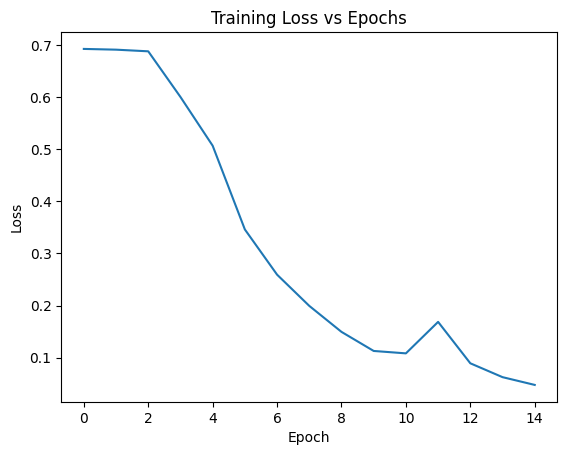

In [62]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

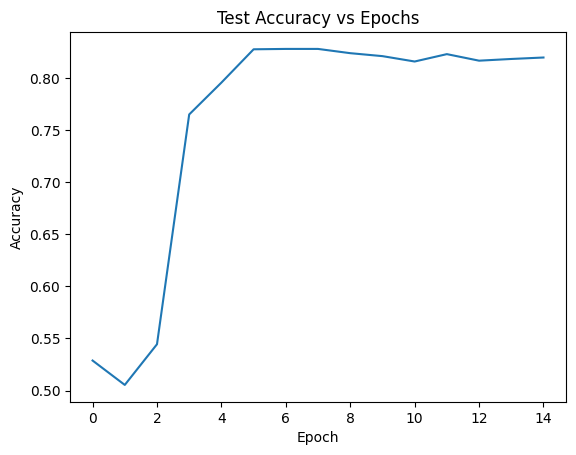

In [63]:
plt.figure()
plt.plot(test_accuracies)
plt.title("Test Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [69]:
def predict(text):
    inputs = tokeniser(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=200
    )
    
    input_ids = inputs["input_ids"].to(device)

    with torch.no_grad():
        output = model(input_ids)
        prob = torch.sigmoid(output).item()

    sentiment = "Positive" if prob >= 0.5 else "Negative"
    return sentiment, prob

In [72]:
import random

def show_examples(dataset, n=10):
    print("\n[EXAMPLES]")
    for i in random.sample(range(len(dataset)), n):
        text = dataset[i]["text"]
        true_label = dataset[i]["label"]

        pred_label, prob = predict(text)

        print("\n-----------------------------")
        print(f"Text: {text[:200]}...")
        print(f"True: {'Positive' if true_label==1 else 'Negative'}")
        print(f"Pred: {pred_label} ({prob:.3f})")

In [76]:
show_examples(dataset["test"], 5)


[EXAMPLES]

-----------------------------
Text: Some of the secondary actors try, really hard. And camera shots in the desert are quite lovely. Otherwise, this film is horrible.<br /><br />William Shatner's character, Harvey, is an amateur screenwr...
True: Negative
Pred: Negative (0.003)

-----------------------------
Text: it's unfortunate that many of the other detractors of this film seem influenced by prior biases. (i.e. anger at the gay characters, thinking french thrillers are bad, etc.) i will admit that i'm unfam...
True: Negative
Pred: Positive (0.986)

-----------------------------
Text: I sat down through 2 hours of pure boredom. I look here on IMDB, even though it is not high on the list, it is in the top 250. I was a little surpised. Even though, yes. I am very impressed with Robin...
True: Negative
Pred: Negative (0.008)

-----------------------------
Text: Looking backwards to that year 2002 when "Furia" was made, one can easily recognize the heralding sings of today's